# NB4 — Well-to-Seismic Tie (REVISED)

## Tujuan
Membangun synthetic seismogram dari model sumur (NB2) dan mengkalibrasi terhadap
data seismik nyata (NB3) untuk validasi konsistensi + kalibrasi noise model (P5).

## Input
- `pipeline_data/01_well_qc/` — CFG, WELL_TOPS
- `pipeline_data/02_well_cond/` — WELL_DFRAMES (dengan VP_GASSMANN, VS_GASSMANN, LITHO)
- `pipeline_data/03_seismic/`  — SEIS_CUBE, seismic_meta, horizons

## Output (`pipeline_data/04_tie/`)
- `wavelet.npz` — wavelet amp + dt_ms + tz + phase_deg
- `WELL_SEIS_TR.pkl` — observed traces per sumur
- `WELL_SYN_TIE.pkl` — synthetic + interpolated logs per sumur
- `NOISE_VAR.json` — **calibrated noise variance per angle (P5)**
- `tie_metrics.json` — CC dan NRMSE per sumur per angle

## Perbaikan dari versi lama
- **P5**: Noise calibration cell — residual synthetic vs observed → `noise_var` per angle
- **P13**: Cell 5.5 QC log → gunakan `plot_utils.plot_well_logs_9track`
- **Plot wavelet**: tambah panel spektrum frekuensi + fase
- **Metrics**: CC (correlation coefficient) + NRMSE per angle
- **BUG FIX**: `save_npy` → `save_npz`


## Cell 1 — Imports + load NB1/NB2/NB3

In [11]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import fftconvolve
from scipy.interpolate import interp1d

sys.path.insert(0, str(Path.cwd()))
from pipeline_io import PipelineIO
import plot_utils

warnings.filterwarnings("ignore")
np.random.seed(42)

print("=" * 72)
print("  NB4 — WELL-TO-SEISMIC TIE")
print("=" * 72)

io_cfg  = PipelineIO(stage="01_well_qc")
CFG     = io_cfg.load_pkl("CFG")
DT      = CFG["seismic_1d"]["dt_s"]
THETA   = np.array(CFG["inversion_2d"]["theta_deg"], dtype=float)
WELL_CFGS = CFG["wells"]
WELL_TOPS = io_cfg.load_pkl("WELL_TOPS")

io_well = PipelineIO(stage="02_well_cond")
WELL_DFRAMES = {wid: io_well.load_df(wid) for wid in CFG["wells"].keys()}
print(f"  ✓ Loaded {len(WELL_DFRAMES)} wells from NB2")

io_seis   = PipelineIO(stage="03_seismic")
seis_cube = io_seis.load_npz("SEIS_CUBE")
twt_win   = io_seis.load_npz("twt_win")["twt_win"]
trace_ax  = io_seis.load_npz("trace_axis_inv")["trace_axis_inv"]
horizons  = io_seis.load_pkl("horizons")
seis_meta = io_seis.load_json("seismic_meta")

twt_win_ms = twt_win * 1000.0
NTR    = int(seis_meta["NTR"])
NT_WIN = int(seis_meta["NT_WIN"])
DT_SEIS = float(seis_meta["DT_SEIS"])

print(f"  ✓ Seismic NTR={NTR}  NT_WIN={NT_WIN}  dt={DT_SEIS*1000:.1f} ms")
print(f"  ✓ Horizons: {list(horizons.keys())}")

# Build long-form seismic DataFrame for trace extraction
_near = seis_cube["near"]
_mid  = seis_cube["mid"]
_far  = seis_cube["far"]
_full = seis_cube["full"]

df_seis_1d = pd.DataFrame({
    "Trace"          : np.repeat(trace_ax, NT_WIN),
    "Time_ms"        : np.tile(twt_win_ms, NTR),
    "Near_Amplitude" : _near.flatten(),
    "Mid_Amplitude"  : _mid.flatten(),
    "Far_Amplitude"  : _far.flatten(),
    "Full_Amplitude" : _full.flatten(),
    "Top_Horizon"    : np.tile(twt_win_ms[0],  NTR * NT_WIN),
    "Base_Horizon"   : np.tile(twt_win_ms[-1], NTR * NT_WIN),
})
SEIS_DATA = {"df_raw": df_seis_1d, "source": "from_nb3"}
print(f"  ✓ Long-form seismic DF: {len(df_seis_1d):,} rows")


  NB4 — WELL-TO-SEISMIC TIE
  ✓ Loaded 2 wells from NB2
  ✓ Seismic NTR=895  NT_WIN=114  dt=4.0 ms
  ✓ Horizons: ['Montara', 'Nome', 'Plover_Reservoir', 'Plover_Volcanics']
  ✓ Long-form seismic DF: 102,030 rows


## Cell 2 — Helper functions

In [12]:
def fill_nan_log(arr):
    arr = np.asarray(arr, dtype=np.float64).copy()
    nans = np.isnan(arr)
    if nans.all():  return np.zeros_like(arr)
    if nans.any():
        idx = np.arange(len(arr))
        arr[nans] = np.interp(idx[nans], idx[~nans], arr[~nans])
    return arr

def normalize_trace(s):
    mx = np.abs(s).max()
    return s / mx if mx > 0 else s

def lookup_top(formation, tops_dict):
    if not tops_dict: return None
    if formation in tops_dict: return float(tops_dict[formation])
    t = formation.replace(" Fm.","").replace(" Fm","").lower().strip()
    for k, v in tops_dict.items():
        kk = k.replace(" Fm.","").replace(" Fm","").lower().strip()
        if kk == t: return float(v)
    return None

def correlation_coefficient(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    n = min(len(a), len(b))
    a, b = a[:n], b[:n]
    valid = np.isfinite(a) & np.isfinite(b)
    if valid.sum() < 5: return np.nan
    a, b = a[valid], b[valid]
    denom = np.std(a) * np.std(b)
    if denom < 1e-12: return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def nrmse(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    n = min(len(a), len(b))
    a, b = a[:n], b[:n]
    valid = np.isfinite(a) & np.isfinite(b)
    if valid.sum() < 5: return np.nan
    a, b = a[valid], b[valid]
    rng = np.max(b) - np.min(b)
    if rng < 1e-12: return np.nan
    return float(np.sqrt(np.mean((a - b)**2)) / rng)

print("[CELL 2] Helpers ready ✓")


[CELL 2] Helpers ready ✓


## Cell 3 — Wavelet load + QC (spektrum frekuensi + fase)

  Loading wavelet ...
  [WAV] dari file: n=30, dt=4.0 ms, phase=0.0°


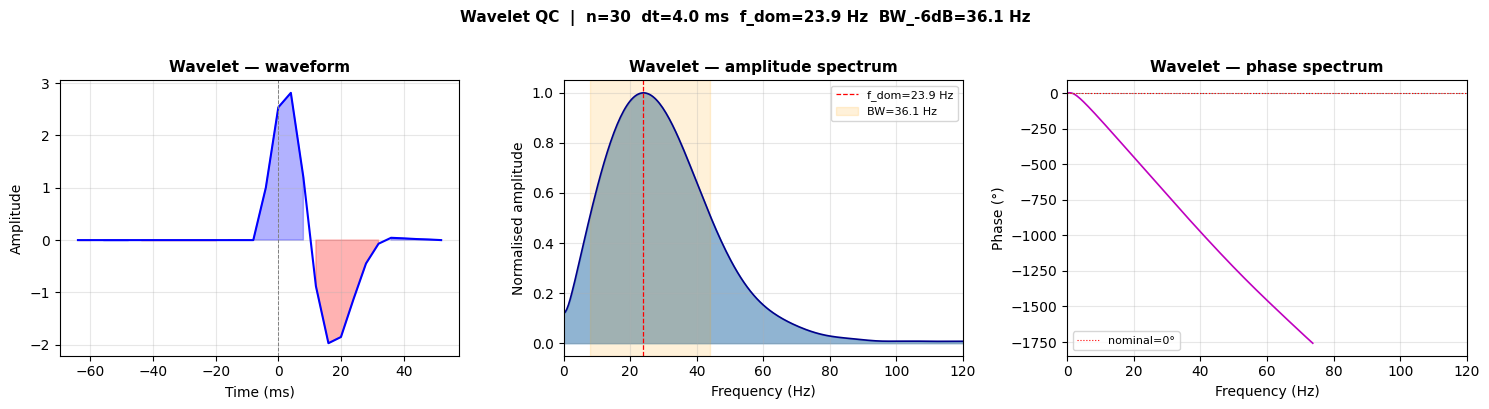

  ✓ Wavelet: dominant=23.9 Hz  -6dB bandwidth=7.8–43.9 Hz


In [13]:
def load_strata_wavelet(filepath, dt_seismic_s):
    filepath = Path(filepath)
    if not filepath.exists():
        raise FileNotFoundError(f"Wavelet not found: {filepath}")
    sr_ms = tz = pr_deg = None
    amp = []; in_amp = False
    with open(filepath, "r") as fh:
        for line in fh:
            s = line.strip()
            if not s: continue
            if s.startswith("~SR"):
                try: sr_ms = float(s.split()[1])
                except: pass
                continue
            if s.startswith("~TZ"):
                try: tz = int(float(s.split()[1]))
                except: pass
                continue
            if s.startswith("~PR"):
                try: pr_deg = float(s.split()[1])
                except: pass
                in_amp = True; continue
            if s.startswith("~"): in_amp = True; continue
            if s.startswith("#") or s.lower().startswith("time"): continue
            if in_amp:
                parts = s.replace(",", " ").split()
                try: amp.append(float(parts[0]) if len(parts)==1 else float(parts[-1]))
                except: pass
    if not amp:
        with open(filepath, "r") as fh:
            for line in fh:
                s = line.strip()
                if not s or s.startswith(("#","~")): continue
                if s.lower().startswith("time"): continue
                parts = s.replace(",", " ").split()
                if len(parts) >= 2:
                    try: amp.append(float(parts[1]))
                    except: pass
    if not amp:
        raise ValueError(f"No amplitude data parsed: {filepath}")
    a = np.asarray(amp, dtype=np.float64)
    if sr_ms is None: sr_ms = dt_seismic_s * 1000.0
    if tz   is None:  tz    = len(a) // 2
    if not np.isclose(sr_ms/1000.0, dt_seismic_s, rtol=0.02):
        t_old = (np.arange(len(a)) - tz) * sr_ms
        dt_ms_t = dt_seismic_s * 1000.0
        t_new = np.arange(t_old[0], t_old[-1] + dt_ms_t*0.5, dt_ms_t)
        a  = np.interp(t_new, t_old, a)
        tz = int(np.argmin(np.abs(t_new)))
        sr_ms = dt_ms_t
    return a, sr_ms, tz, pr_deg


def ricker_wavelet(f=24.0, dt=0.004, n=81):
    tw = (np.arange(n) - n//2) * dt
    w  = (1 - 2*(np.pi*f*tw)**2) * np.exp(-(np.pi*f*tw)**2)
    return w / max(np.max(np.abs(w)), 1e-12), dt*1000, n//2


print("  Loading wavelet ...")
try:
    wav, dt_w, tz_w, pr_deg_w = load_strata_wavelet(CFG["wavelet"]["file"], DT)
    print(f"  [WAV] dari file: n={len(wav)}, dt={dt_w:.1f} ms"
          + (f", phase={pr_deg_w:.1f}°" if pr_deg_w is not None else ""))
except Exception as e:
    print(f"  [WAV] {type(e).__name__}: {e} — fallback Ricker "
          f"{CFG['wavelet']['fallback_freq_hz']} Hz")
    wav, dt_w, tz_w = ricker_wavelet(CFG["wavelet"]["fallback_freq_hz"], DT,
                                      CFG["wavelet"]["fallback_n"])
    pr_deg_w = None

WAVELET = {"amp": wav, "dt_ms": dt_w, "tz": tz_w, "phase_deg": pr_deg_w}

# ─── QC plot: waveform + amplitude spectrum + phase spectrum ───
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Waveform
t_axis = (np.arange(len(wav)) - tz_w) * DT * 1000
axes[0].plot(t_axis, wav, "b-", lw=1.5)
axes[0].fill_between(t_axis, 0, wav, where=(wav>=0), color="blue", alpha=0.30)
axes[0].fill_between(t_axis, 0, wav, where=(wav<0),  color="red",  alpha=0.30)
axes[0].axvline(0, color="gray", lw=0.7, ls="--")
axes[0].set_xlabel("Time (ms)", fontsize=10)
axes[0].set_ylabel("Amplitude", fontsize=10)
axes[0].set_title("Wavelet — waveform", fontsize=11, fontweight="bold")
axes[0].grid(True, alpha=0.3)

# Amplitude spectrum
W_fft  = np.fft.rfft(wav, n=512)
freqs  = np.fft.rfftfreq(512, d=DT)
amp_sp = np.abs(W_fft)
amp_sp /= amp_sp.max() + 1e-12
axes[1].fill_between(freqs, 0, amp_sp, color="steelblue", alpha=0.60)
axes[1].plot(freqs, amp_sp, color="darkblue", lw=1.2)
f_dom  = freqs[np.argmax(amp_sp)]
thresh = 0.50
bw_lo  = freqs[amp_sp >= thresh][0]  if (amp_sp >= thresh).any() else 0
bw_hi  = freqs[amp_sp >= thresh][-1] if (amp_sp >= thresh).any() else 0
axes[1].axvline(f_dom, color="red", lw=0.9, ls="--", label=f"f_dom={f_dom:.1f} Hz")
axes[1].axvspan(bw_lo, bw_hi, alpha=0.15, color="orange", label=f"BW={bw_hi-bw_lo:.1f} Hz")
axes[1].set_xlabel("Frequency (Hz)", fontsize=10)
axes[1].set_ylabel("Normalised amplitude", fontsize=10)
axes[1].set_title("Wavelet — amplitude spectrum", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, min(120, 1/(2*DT)))

# Phase spectrum (unwrapped)
phase_sp = np.angle(W_fft, deg=True)
phase_sp = np.unwrap(phase_sp * np.pi / 180) * 180 / np.pi
valid_f  = (amp_sp > 0.05)
axes[2].plot(freqs[valid_f], phase_sp[valid_f], "m-", lw=1.2)
axes[2].axhline(0, color="gray", lw=0.6, ls="--")
if pr_deg_w is not None:
    axes[2].axhline(pr_deg_w, color="red", lw=0.8, ls=":", label=f"nominal={pr_deg_w:.0f}°")
axes[2].set_xlabel("Frequency (Hz)", fontsize=10)
axes[2].set_ylabel("Phase (°)", fontsize=10)
axes[2].set_title("Wavelet — phase spectrum", fontsize=11, fontweight="bold")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, min(120, 1/(2*DT)))

plt.suptitle(f"Wavelet QC  |  n={len(wav)}  dt={dt_w:.1f} ms  f_dom={f_dom:.1f} Hz  "
             f"BW_-6dB={bw_hi-bw_lo:.1f} Hz",
             fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()
print(f"  ✓ Wavelet: dominant={f_dom:.1f} Hz  -6dB bandwidth={bw_lo:.1f}–{bw_hi:.1f} Hz")


## Cell 4 — Forward modeling + extraction utilities

In [14]:
def compute_rc(vp, rho):
    ai = vp * rho
    rc = np.zeros(len(ai) - 1)
    denom = ai[1:] + ai[:-1]
    mask  = np.abs(denom) > 1e-9
    rc[mask] = (ai[1:][mask] - ai[:-1][mask]) / denom[mask]
    return rc


def build_G_fft_wavelet(vp0, vs0, rho0, theta_deg, wav):
    """Forward operator untuk SATU angle + SATU wavelet."""
    nt = len(vp0)
    G  = np.zeros((nt-1, 3*nt), dtype=np.float64)
    th = np.deg2rad(theta_deg)
    vp_mid  = 0.5*(vp0[1:]  + vp0[:-1])
    vs_mid  = 0.5*(vs0[1:]  + vs0[:-1])
    rho_mid = 0.5*(rho0[1:] + rho0[:-1])
    sin2 = np.sin(th)**2; tan2 = np.tan(th)**2
    vpvs2 = (vs_mid / (vp_mid + 1e-9))**2
    a =  0.5*(1.0 + tan2)
    b = -4.0*vpvs2*sin2
    c =  0.5*(1.0 - 4.0*vpvs2*sin2)
    rows = np.arange(nt-1)
    G[rows, rows]        = -a/(2*vp_mid  + 1e-9)
    G[rows, rows+1]      =  a/(2*vp_mid  + 1e-9)
    G[rows, nt+rows]     = -b/(2*vs_mid  + 1e-9)
    G[rows, nt+rows+1]   =  b/(2*vs_mid  + 1e-9)
    G[rows, 2*nt+rows]   = -c/(2*rho_mid + 1e-9)
    G[rows, 2*nt+rows+1] =  c/(2*rho_mid + 1e-9)
    for col in range(3*nt):
        G[:, col] = signal.fftconvolve(G[:, col], wav, mode="same")[:nt-1]
    return G


def build_synthetic_AVO(vp, vs, rho, theta_deg, wavelets):
    """
    wavelets: dict {"near": wav_arr, "mid": wav_arr, "far": wav_arr}
              atau list [wav_near, wav_mid, wav_far] sesuai urutan theta_deg
              atau single array (backward compatible)
    """
    vp  = fill_nan_log(np.asarray(vp,  float))
    vs  = fill_nan_log(np.asarray(vs,  float))
    rho = fill_nan_log(np.asarray(rho, float))

    # Normalisasi input wavelet ke list
    if isinstance(wavelets, dict):
        wav_list = [wavelets[k]["amp"] for k in ["near", "mid", "far"]]
    elif isinstance(wavelets, np.ndarray) or (hasattr(wavelets, '__len__')
         and not isinstance(wavelets[0], np.ndarray)):
        # Single wavelet array → broadcast ke semua angle
        wav_list = [wavelets] * len(theta_deg)
    else:
        wav_list = wavelets  # sudah list of arrays

    out = {}
    for th, wav in zip(theta_deg, wav_list):
        G = build_G_fft_wavelet(vp, vs, rho, th, wav)
        m = np.concatenate([vp, vs, rho])
        out[th] = (G @ m)[:len(vp)-1]
    return out


print("[CELL 4] Forward modeling utilities (per-angle wavelet) ready ✓")


def extract_trace_at_well(seis_data, trace_idx_target):
    df  = seis_data["df_raw"]
    avail = df["Trace"].unique()
    t_closest = avail[np.argmin(np.abs(avail - trace_idx_target))]
    sub = df[df["Trace"] == t_closest].sort_values("Time_ms").reset_index(drop=True)
    return {
        "trace_idx": int(t_closest),
        "time_ms"  : sub["Time_ms"].values.astype(float),
        "near"     : sub["Near_Amplitude"].values.astype(float),
        "mid"      : sub["Mid_Amplitude"].values.astype(float),
        "far"      : sub["Far_Amplitude"].values.astype(float),
        "full"     : sub["Full_Amplitude"].values.astype(float),
        "top"      : float(sub["Top_Horizon"].iloc[0]),
        "base"     : float(sub["Base_Horizon"].iloc[0]),
    }


def amp_normalize_pair(synthetic, observed, method="leastsq"):
    syn = np.asarray(synthetic, float); obs = np.asarray(observed, float)
    n   = min(len(syn), len(obs)); syn = syn[:n]; obs = obs[:n]
    if method == "leastsq":
        k = float(syn @ obs) / (float(syn @ syn) + 1e-12)
    else:
        k = np.max(np.abs(obs)) / (np.max(np.abs(syn)) + 1e-12)
    return syn * k, obs, k


print("[CELL 4] Forward modeling utilities (per-angle wavelet) ready ✓")

[CELL 4] Forward modeling utilities (per-angle wavelet) ready ✓
[CELL 4] Forward modeling utilities (per-angle wavelet) ready ✓


## Cell 5 — 13-Track tie plot function

In [15]:
def plot_well_to_seismic_tie(well_name, twt_grid, log_dict, rc, syn_norm,
                              seis_norm, theta_deg, k_scales, tops_time=None,
                              tie_metrics=None, figsize=(24, 12)):
    nt = len(twt_grid)
    twt_s = twt_grid[:nt-1]

    fig, axes = plt.subplots(1, 13, figsize=figsize, sharey=True)
    titles = ["GR/VSH","VP_model","RHO_sat","PI_model","RC",
              f"Syn N({theta_deg[0]:.0f}°)",
              f"Syn M({theta_deg[1]:.0f}°)",
              f"Syn F({theta_deg[2]:.0f}°)",
              "Syn Full",
              f"Seis N({theta_deg[0]:.0f}°)",
              f"Seis M({theta_deg[1]:.0f}°)",
              f"Seis F({theta_deg[2]:.0f}°)",
              "Seis Full"]
    for ax, t in zip(axes, titles):
        ax.set_title(t, fontsize=7.5, fontweight="bold")

    # GR/VSH
    ax = axes[0]
    if log_dict.get("GR") is not None:
        ax.plot(log_dict["GR"], twt_grid, "k-", lw=0.7)
        ax.set_xlim(0, 200)
    if log_dict.get("VSH") is not None:
        ax2 = ax.twiny()
        ax2.plot(log_dict["VSH"], twt_grid, color="#2ca02c", lw=0.7, ls="--")
        ax2.set_xlim(0, 1); ax2.tick_params(axis="x", colors="#2ca02c", labelsize=6)

    # VP_model
    axes[1].plot(log_dict.get("VP_log", np.full(nt, np.nan)), twt_grid,
                 "k-", lw=0.6, alpha=0.5, label="raw")
    axes[1].plot(log_dict.get("VP_sm",  np.full(nt, np.nan)), twt_grid,
                 "b-", lw=1.0, label="smooth")
    axes[1].legend(fontsize=5)

    # RHO_sat
    axes[2].plot(log_dict.get("RHO_log", np.full(nt, np.nan)), twt_grid,
                 "k-", lw=0.6, alpha=0.5)
    axes[2].plot(log_dict.get("RHO_sm",  np.full(nt, np.nan)), twt_grid,
                 "r-", lw=1.0)

    # PI_model
    ai_log = log_dict.get("VP_log", np.full(nt, np.nan)) *              log_dict.get("RHO_log", np.ones(nt))
    ai_sm  = log_dict.get("VP_sm",  np.full(nt, np.nan)) *              log_dict.get("RHO_sm",  np.ones(nt))
    axes[3].plot(ai_log, twt_grid, "k-", lw=0.6, alpha=0.5)
    axes[3].plot(ai_sm,  twt_grid, color="purple", lw=1.0)

    # RC
    axes[4].fill_betweenx(twt_s, 0, rc, where=(rc>=0), color="blue", alpha=0.55)
    axes[4].fill_betweenx(twt_s, 0, rc, where=(rc<0),  color="red",  alpha=0.55)
    axes[4].plot(rc, twt_s, "k-", lw=0.4)

    # Synthetics
    syn_full = np.mean([syn_norm[t] for t in theta_deg], axis=0)
    for i, (th, col) in enumerate(zip(theta_deg,
                                       ["#1565C0","#2E7D32","#E65100","#4527A0"])):
        sy = syn_norm[th] if i < 3 else syn_full
        axes[5+i].fill_betweenx(twt_s, 0, sy, where=(sy>=0), color=col, alpha=0.55)
        axes[5+i].fill_betweenx(twt_s, 0, sy, where=(sy<0),  color=col, alpha=0.22)
        axes[5+i].plot(sy, twt_s, "k-", lw=0.4)

    # Observed
    for i, (key, col) in enumerate(zip(["near","mid","far","full"],
                                        ["#0D47A1","#1B5E20","#BF360C","#311B92"])):
        se = seis_norm[key]
        axes[9+i].fill_betweenx(twt_grid, 0, se, where=(se>=0), color=col, alpha=0.55)
        axes[9+i].fill_betweenx(twt_grid, 0, se, where=(se<0),  color=col, alpha=0.22)
        axes[9+i].plot(se, twt_grid, "k-", lw=0.4)

    # Common
    ymin, ymax = float(twt_grid.min()), float(twt_grid.max())
    for ax in axes:
        ax.set_ylim(ymax, ymin); ax.grid(True, alpha=0.25, axis="y")
        ax.tick_params(labelsize=6)
    axes[0].set_ylabel("TWT (ms)", fontsize=9)

    if tops_time:
        for ax in axes:
            for nm, tt in tops_time.items():
                if ymin <= tt <= ymax:
                    ax.axhline(tt, color="black", ls="--", lw=0.7, alpha=0.7)
        for nm, tt in tops_time.items():
            if ymin <= tt <= ymax:
                axes[0].text(0.02, tt, f" {nm}",
                             transform=axes[0].get_yaxis_transform(),
                             fontsize=6, va="center",
                             bbox=dict(boxstyle="round,pad=0.1",
                                       fc="yellow", alpha=0.80, lw=0))

    # Metrics box
    if tie_metrics:
        met_txt = "  ".join(
            [f"θ={int(th)}°: CC={tie_metrics.get(f'CC_{int(th)}',np.nan):.2f} "
             f"NRMSE={tie_metrics.get(f'NRMSE_{int(th)}',np.nan):.3f}"
             for th in theta_deg])
        fig.text(0.5, -0.01, met_txt, ha="center", fontsize=8,
                 bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow",
                           ec="orange", alpha=0.90))

    fig.suptitle(f"Well-to-Seismic Tie — {well_name}",
                 fontsize=12, fontweight="bold", y=1.005)
    plt.tight_layout()
    plt.show()

print("[CELL 5] Tie plot function ready ✓")


[CELL 5] Tie plot function ready ✓


## Cell 5.5 — QC Log Plot menggunakan `plot_utils.plot_well_logs_9track`

**Fix (P13)**: Menggunakan template 9-track terpusat dari `plot_utils` — konsisten dengan NB1/NB2.


  QC LOG PLOT (9-track, TWT domain)

  Plotting Poseidon-1 — depth axis: DEPTH


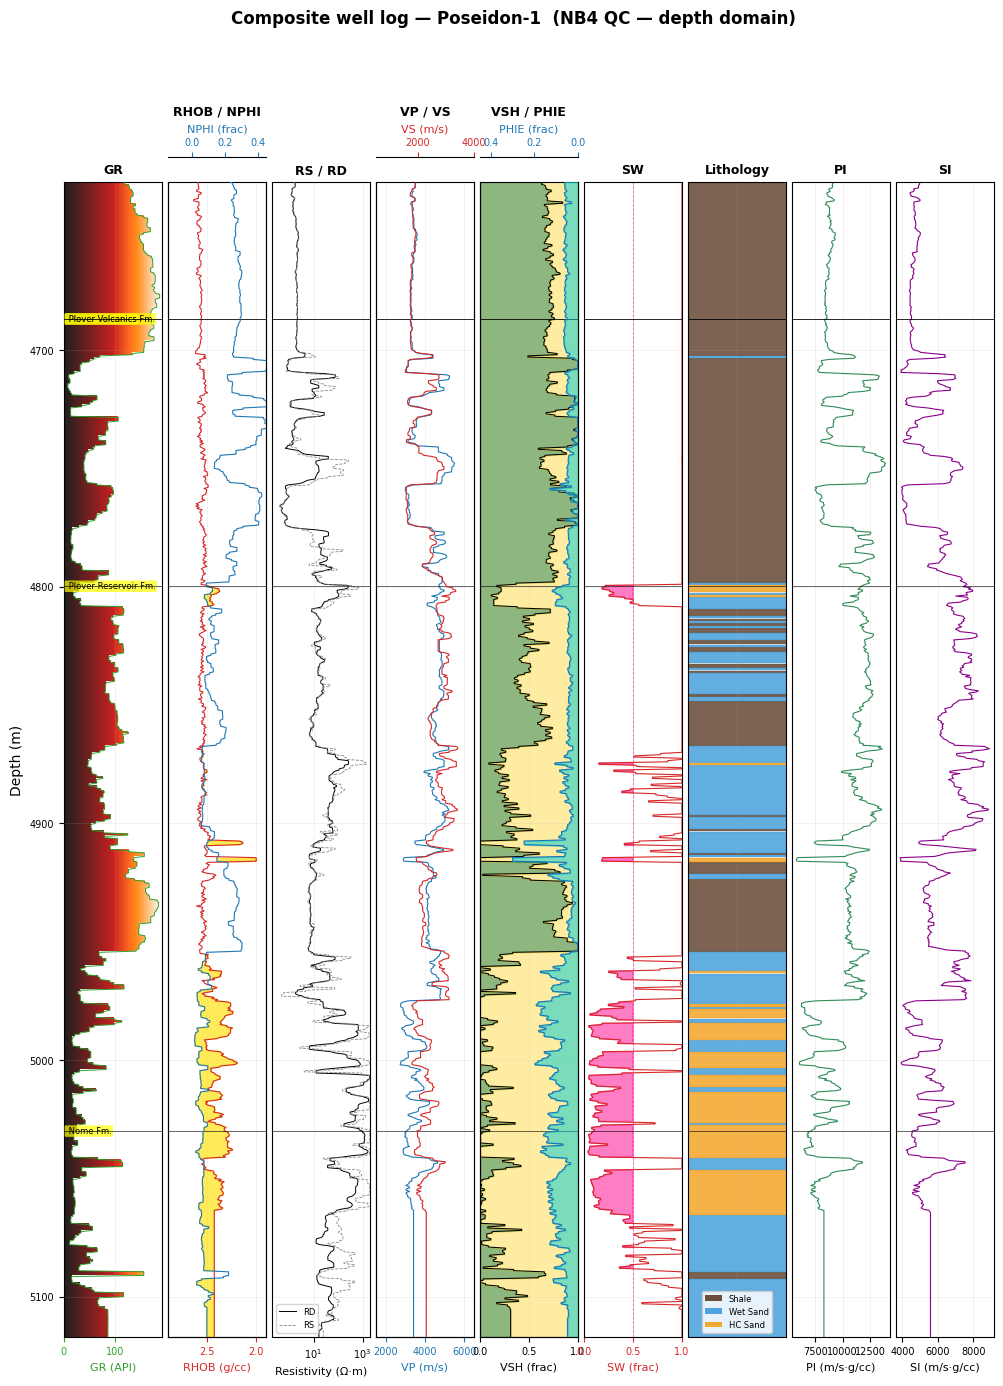


  Plotting Boreas-1 — depth axis: DEPTH


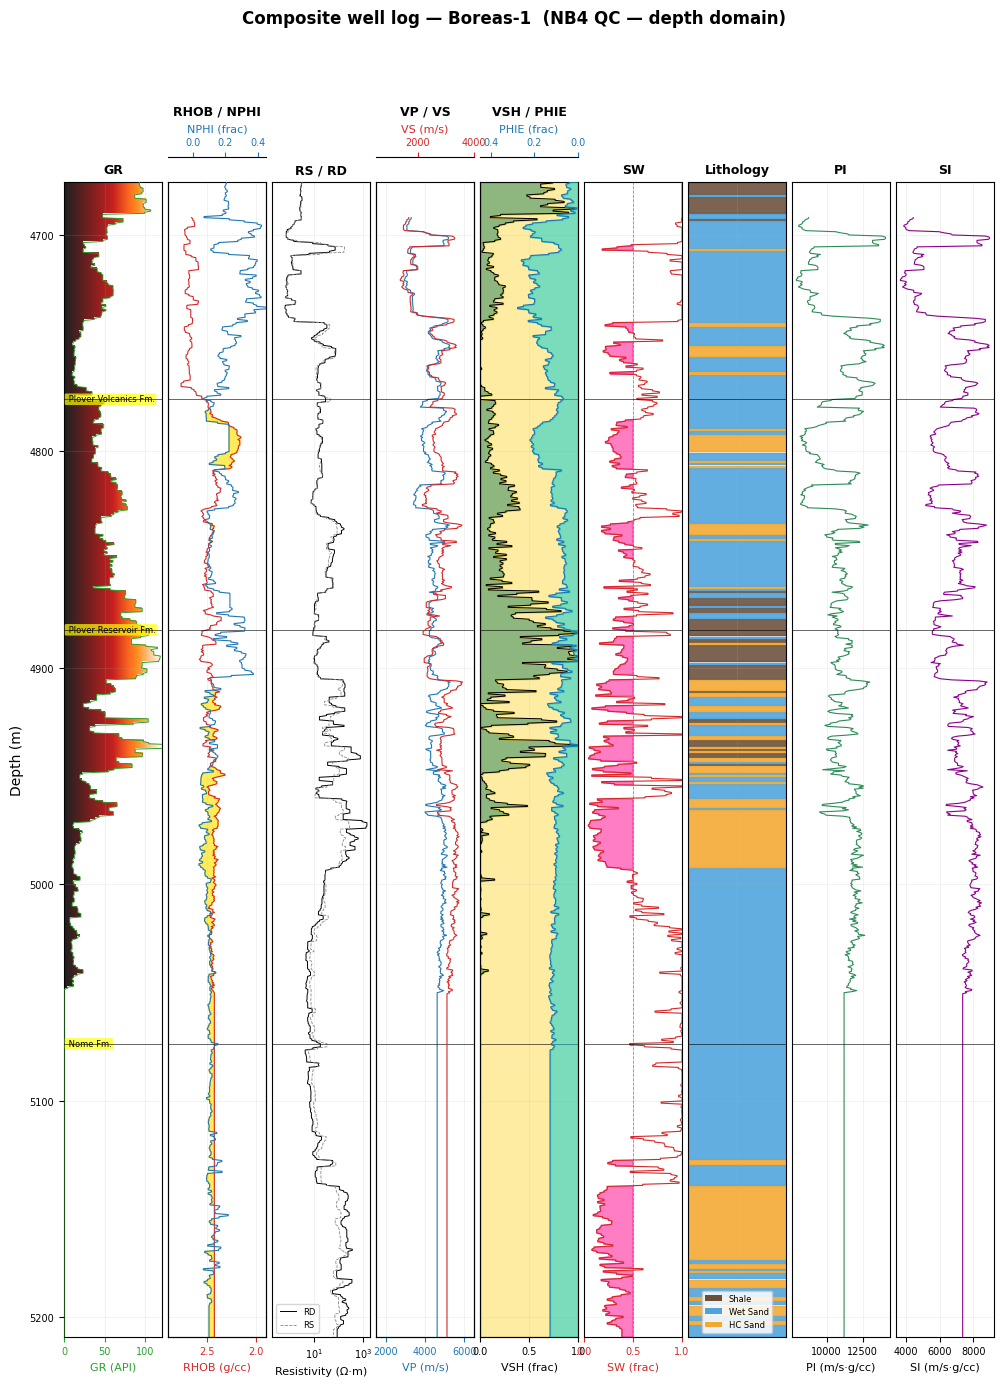

In [16]:
print("\n" + "=" * 72)
print("  QC LOG PLOT (9-track, TWT domain)")
print("=" * 72)

for well_id, df_w in WELL_DFRAMES.items():
    tops = WELL_TOPS.get(well_id, {})

    # Rename model columns agar plot_utils bisa kenali
    df_plot = df_w.rename(columns={
        "VP"  :  "VP",
        "VS"  :  "VS",
        "RHOB" : "RHOB",
        "PI"  :  "PI",
        "SI"  :  "SI",
    })

    # Gunakan DEPTH domain (TWT jika ada di TIME column)
    depth_col = "DEPTH" if "DEPTH" in df_plot.columns else "TIME"
    depth_lbl  = "Depth (m)" if depth_col == "DEPTH" else "TWT (s)"

    print(f"\n  Plotting {well_id} — depth axis: {depth_col}")
    plot_utils.plot_well_logs_9track(
        df_plot, well_id=well_id,
        tops=tops,
        depth_col=depth_col,
        depth_label=depth_lbl,
        title_suffix="  (NB4 QC — depth domain)",
    )


## Cell 6 — Run well-to-seismic tie per sumur


  WELL-TO-SEISMIC TIE

-----------------------------------------------------------------
  TIE: Poseidon-1  (trace #415)
-----------------------------------------------------------------
  [EXTRACT] nt=114  dt=4.00 ms  TWT=3000.0–3452.0 ms
  [LOG-TWT] VP valid: 61/114
    θ=12°: CC=+0.371  NRMSE=0.1350  k_scale=0.8470
    θ=24°: CC=+0.616  NRMSE=0.1362  k_scale=2.7942
    θ=36°: CC=+0.457  NRMSE=0.1450  k_scale=3.1876


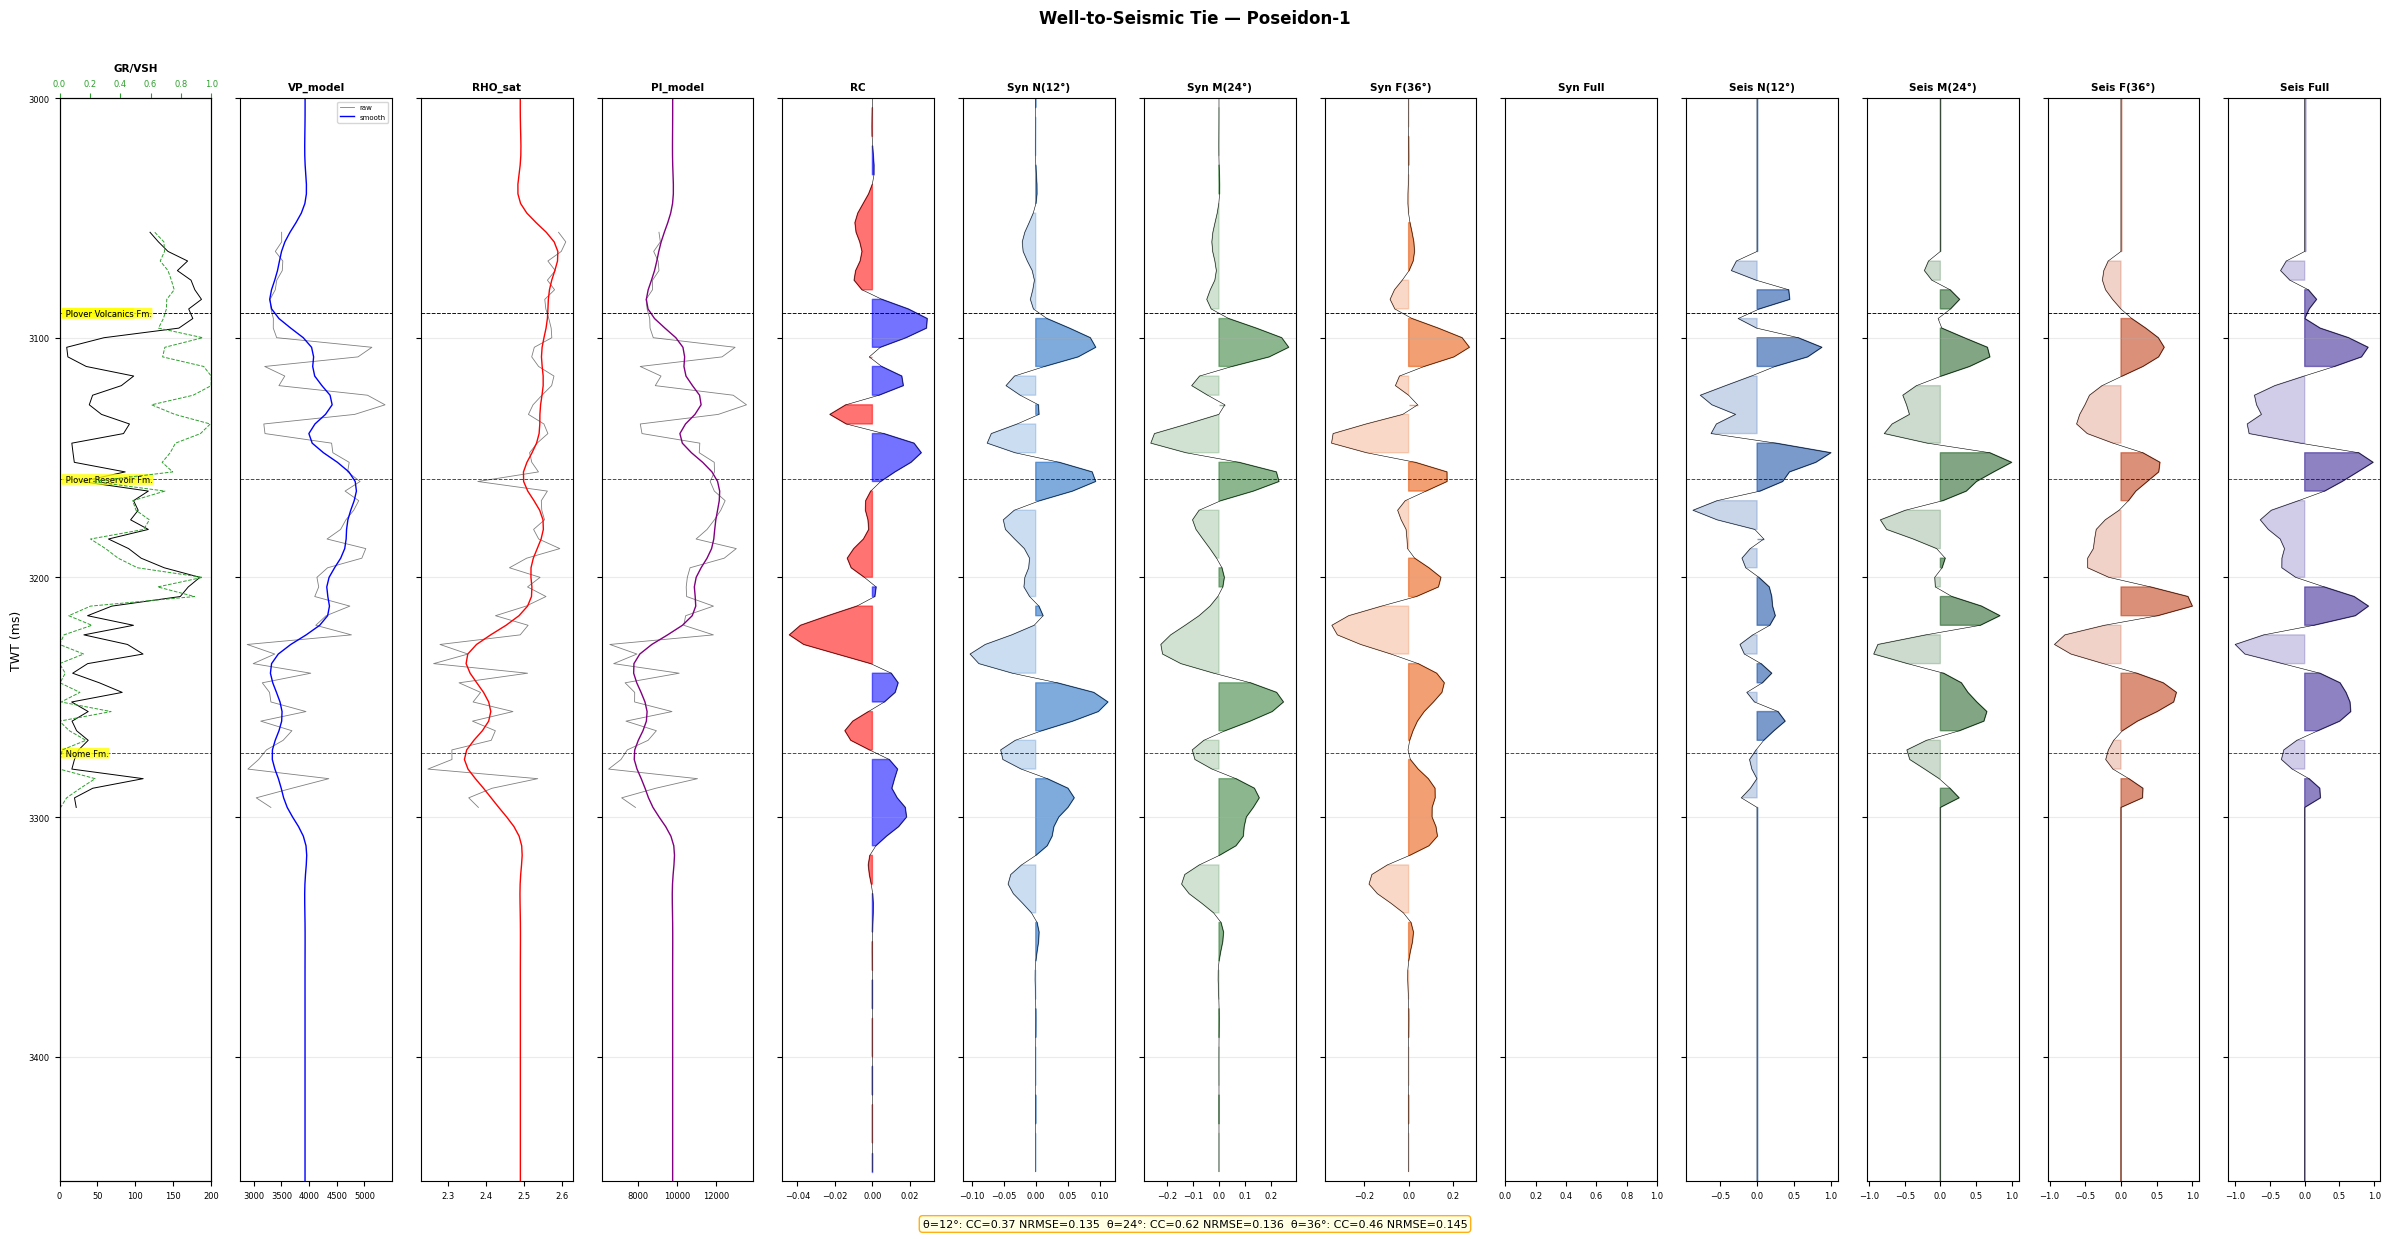


-----------------------------------------------------------------
  TIE: Boreas-1  (trace #603)
-----------------------------------------------------------------
  [EXTRACT] nt=114  dt=4.00 ms  TWT=3000.0–3452.0 ms
  [LOG-TWT] VP valid: 54/114
    θ=12°: CC=+0.580  NRMSE=0.1117  k_scale=1.0150
    θ=24°: CC=+0.635  NRMSE=0.1086  k_scale=2.2836
    θ=36°: CC=+0.288  NRMSE=0.1420  k_scale=2.2244


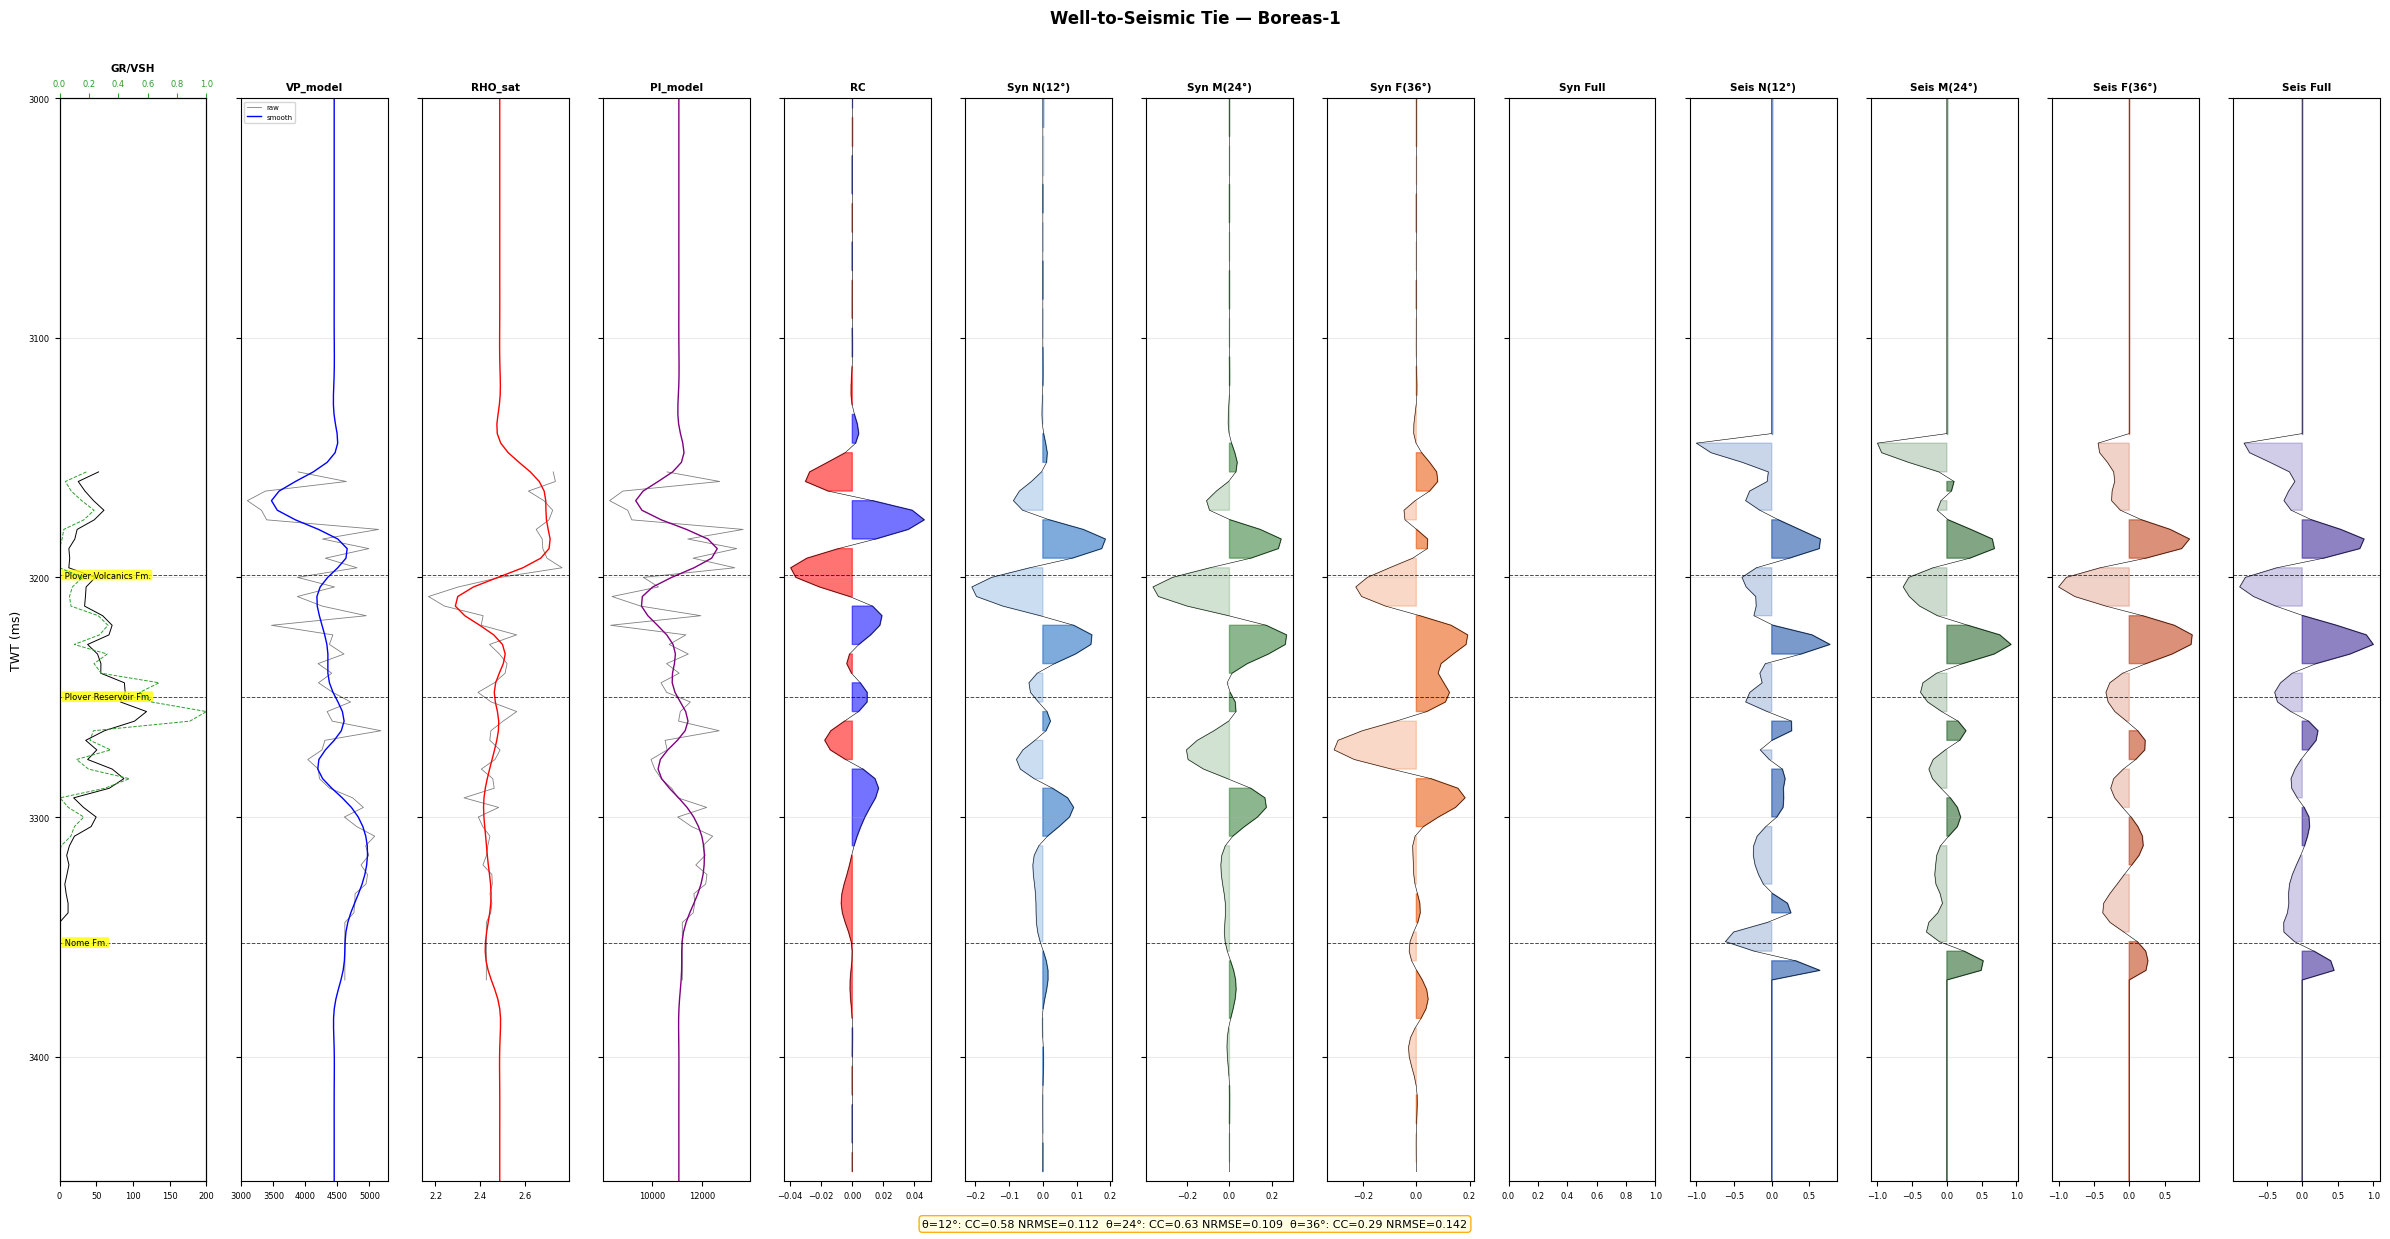


  ✓ Tie selesai untuk semua sumur


In [17]:
WELL_SEIS_TR = {}
WELL_SYN_TIE = {}

b_but, a_but = signal.butter(N=3, Wn=0.25)

print("\n" + "=" * 72)
print("  WELL-TO-SEISMIC TIE")
print("=" * 72)

for well_id, wcfg in WELL_CFGS.items():
    print("\n" + "-" * 65)
    print(f"  TIE: {well_id}  (trace #{wcfg['trace_idx']})")
    print("-" * 65)

    tr       = extract_trace_at_well(SEIS_DATA, wcfg["trace_idx"])
    twt_grid = tr["time_ms"]
    nt       = len(twt_grid)
    dt_ms    = float(np.median(np.diff(twt_grid)))
    print(f"  [EXTRACT] nt={nt}  dt={dt_ms:.2f} ms  "
          f"TWT={twt_grid[0]:.1f}–{twt_grid[-1]:.1f} ms")

    df_w = WELL_DFRAMES[well_id]
    vp_col  = "VP" if "VP" in df_w.columns else "VP"
    vs_col  = "VS" if "VS" in df_w.columns else "VS"
    rho_col = "RHOB" if "RHOB" in df_w.columns else "RHOB"

    if "TIME" not in df_w.columns:
        print(f"  [SKIP] {well_id}: kolom TIME tidak ada"); continue

    df_w2 = (df_w.dropna(subset=["TIME", vp_col, vs_col, rho_col])
                 .sort_values("TIME").reset_index(drop=True))

    def _interp(col):
        if col not in df_w2.columns: return np.full(nt, np.nan)
        t_ms = df_w2["TIME"].values.copy()
        if t_ms[~np.isnan(t_ms)].max() < 100: t_ms *= 1000.0
        return interp1d(t_ms, df_w2[col].values,
                        bounds_error=False, fill_value=np.nan)(twt_grid)

    Vp_w  = _interp(vp_col)
    Vs_w  = _interp(vs_col)
    Rho_w = _interp(rho_col)
    GR_w  = _interp("GR")
    VSH_w = _interp("VSH")

    n_valid = int(np.isfinite(Vp_w).sum())
    print(f"  [LOG-TWT] VP valid: {n_valid}/{nt}")
    if n_valid < 5:
        print(f"  [SKIP] overlap tidak cukup"); continue

    def _smooth(a):
        return signal.filtfilt(b_but, a_but,
                               np.nan_to_num(a, nan=float(np.nanmean(a) if np.isfinite(a).any() else 0)))

    Vp_sm  = _smooth(Vp_w)
    Vs_sm  = _smooth(Vs_w)
    Rho_sm = _smooth(Rho_w)

    syn_avo = build_synthetic_AVO(Vp_sm, Vs_sm, Rho_sm, THETA, WAVELET["amp"])
    rc_acoust = compute_rc(Vp_sm, Rho_sm)

    obs_pairs = {THETA[0]: tr["near"], THETA[1]: tr["mid"], THETA[2]: tr["far"]}
    syn_norm = {}; seis_norm_plot = {}; k_list = []
    for th in THETA:
        sy = syn_avo[th]; ob = obs_pairs[th][:nt-1]
        sy_n, ob_n, k = amp_normalize_pair(sy, ob)
        syn_norm[th] = sy_n; k_list.append(k)

    seis_norm_plot = {
        "near": normalize_trace(tr["near"]),
        "mid" : normalize_trace(tr["mid"]),
        "far" : normalize_trace(tr["far"]),
        "full": normalize_trace(tr["full"]),
    }

    # Formation tops di TWT
    tops_time = {}
    for fm, zd in (WELL_TOPS.get(well_id) or {}).items():
        df_t = df_w2.dropna(subset=["TIME"])
        if len(df_t) == 0: continue
        t_ms_all = df_t["TIME"].values * (1000 if df_t["TIME"].max() < 100 else 1)
        z_all    = df_t["DEPTH"].values if "DEPTH" in df_t.columns else None
        if z_all is None: continue
        tt = np.interp(float(zd), z_all, t_ms_all,
                       left=np.nan, right=np.nan)
        if np.isfinite(tt): tops_time[fm] = float(tt)

    # ── Compute tie metrics ──
    tie_metrics = {}
    for th, key in zip(THETA, ["near","mid","far"]):
        sy = syn_norm[th]
        ob = obs_pairs[th][:len(sy)]
        tie_metrics[f"CC_{int(th)}"]    = correlation_coefficient(sy, ob)
        tie_metrics[f"NRMSE_{int(th)}"] = nrmse(sy, ob)
        print(f"    θ={int(th):2d}°: CC={tie_metrics[f'CC_{int(th)}']:+.3f}  "
              f"NRMSE={tie_metrics[f'NRMSE_{int(th)}']:.4f}  k_scale={k_list[list(THETA).index(th)]:.4f}")

    WELL_SEIS_TR[well_id] = tr
    WELL_SYN_TIE[well_id] = {
        "twt_grid" : twt_grid,
        "Vp_w"     : Vp_w,   "Vs_w"  : Vs_w,   "Rho_w"  : Rho_w,
        "Vp_sm"    : Vp_sm,  "Vs_sm" : Vs_sm,  "Rho_sm" : Rho_sm,
        "syn_avo"  : {int(k): v for k,v in syn_avo.items()},
        "rc"       : rc_acoust,
        "k_scales" : k_list,
        "tops_time": tops_time,
        "metrics"  : tie_metrics,
    }

    plot_well_to_seismic_tie(
        well_id, twt_grid,
        log_dict={"GR":GR_w,"VSH":VSH_w,
                  "VP_log":Vp_w,"VP_sm":Vp_sm,
                  "RHO_log":Rho_w,"RHO_sm":Rho_sm},
        rc=rc_acoust, syn_norm=syn_norm,
        seis_norm=seis_norm_plot,
        theta_deg=THETA, k_scales=k_list,
        tops_time=tops_time,
        tie_metrics=tie_metrics,
    )

print("\n  ✓ Tie selesai untuk semua sumur")


## Cell 6.5 — Synthetic vs seismic trace (per angle, smooth)

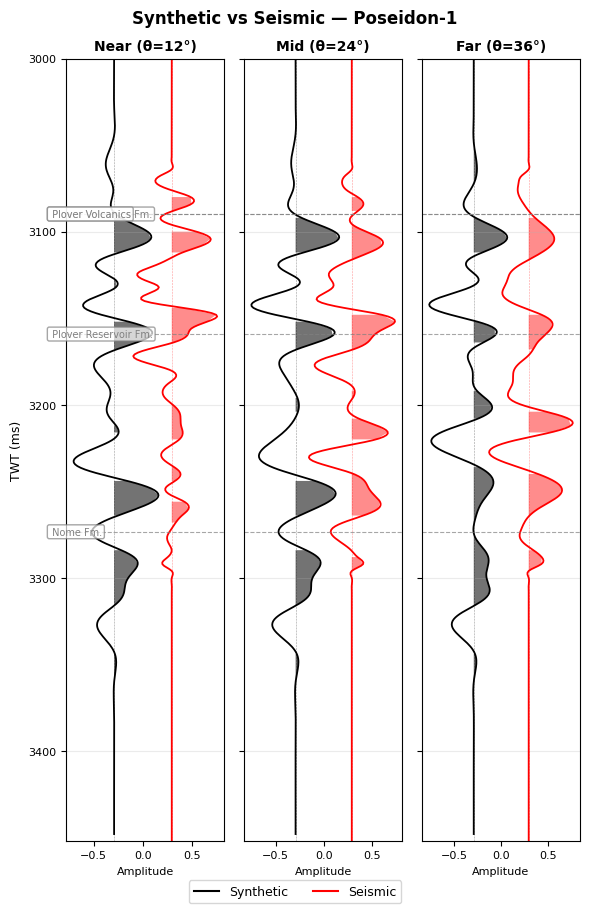

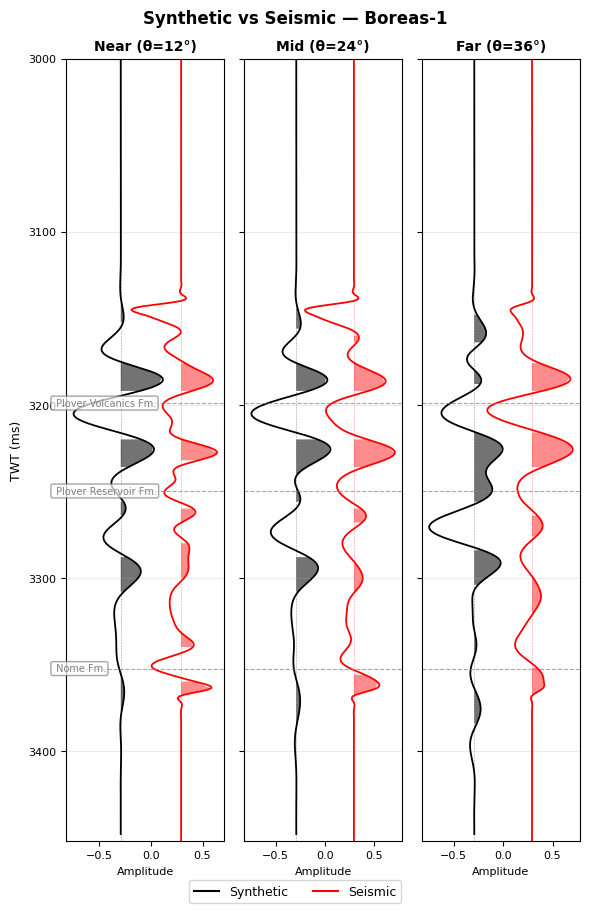

In [18]:
from scipy.interpolate import make_interp_spline

def plot_syn_vs_seis(well_name, twt_grid, syn_norm, seis_tr, theta_deg,
                      tops_time=None, smooth_fac=4):
    angle_info = [(theta_deg[0], "near"), (theta_deg[1], "mid"), (theta_deg[2], "far")]
    fig, axes  = plt.subplots(1, 3, figsize=(6, 9), sharey=True)
    fig.suptitle(f"Synthetic vs Seismic — {well_name}", fontsize=12, fontweight="bold")

    twt_syn  = twt_grid[:len(twt_grid) - 1]
    twt_seis = seis_tr["time_ms"]

    def _smooth(x, y):
        x = np.asarray(x, float); y = np.asarray(y, float)
        m = np.isfinite(y)
        if m.sum() < 4: return x, y
        xf = np.linspace(x[m][0], x[m][-1], m.sum() * smooth_fac)
        return xf, make_interp_spline(x[m], y[m], k=3)(xf)

    scale = 0.45
    for ax, (th, key), label in zip(axes, angle_info,
        [f"Near (θ={int(theta_deg[0])}°)", f"Mid (θ={int(theta_deg[1])}°)",
         f"Far (θ={int(theta_deg[2])}°)"]):
        sy = np.asarray(syn_norm[th], float)
        se = np.asarray(seis_tr[key], float)
        sy_n = sy / (np.nanmax(np.abs(sy)) + 1e-12) * scale
        se_n = se / (np.nanmax(np.abs(se)) + 1e-12) * scale
        off  = scale * 0.65
        sy_o = sy_n - off; se_o = se_n + off

        ax.fill_betweenx(twt_syn,  -off, sy_o, where=(sy_o >= -off),
                         color="black", alpha=0.55, lw=0)
        ax.fill_betweenx(twt_seis, +off, se_o, where=(se_o >= +off),
                         color="red",   alpha=0.45, lw=0)

        ts, ys = _smooth(twt_syn, sy_o)
        te, ye = _smooth(twt_seis, se_o)
        ax.plot(ys, ts, color="black", lw=1.3, label="Synthetic")
        ax.plot(ye, te, color="red",   lw=1.3, label="Seismic")
        ax.axvline(-off, color="black", lw=0.4, ls="--", alpha=0.4)
        ax.axvline(+off, color="red",   lw=0.4, ls="--", alpha=0.4)
        ax.set_title(label, fontsize=10, fontweight="bold")
        ax.set_xlabel("Amplitude", fontsize=8)
        ax.grid(True, axis="y", alpha=0.25)
        ax.tick_params(labelsize=8)

    axes[0].set_ylabel("TWT (ms)", fontsize=9)
    ymin, ymax = float(twt_grid.min()), float(twt_grid.max())
    for ax in axes: ax.set_ylim(ymax, ymin)

    if tops_time:
        for ax in axes:
            for nm, tt in tops_time.items():
                if ymin <= tt <= ymax:
                    ax.axhline(tt, color="gray", ls="--", lw=0.8, alpha=0.7)
        for nm, tt in tops_time.items():
            if ymin <= tt <= ymax:
                axes[0].text(-0.95, tt, f" {nm}", fontsize=7, va="center",
                             color="gray",
                             bbox=dict(boxstyle="round,pad=0.2",
                                       fc="white", ec="gray", alpha=0.7))

    from matplotlib.lines import Line2D
    fig.legend(handles=[Line2D([0],[0],color="black",lw=1.5,label="Synthetic"),
                        Line2D([0],[0],color="red",  lw=1.5,label="Seismic")],
               loc="lower center", ncol=2, fontsize=9,
               bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(); plt.show()


for well_id in WELL_SYN_TIE:
    tie = WELL_SYN_TIE[well_id]
    plot_syn_vs_seis(
        well_id, tie["twt_grid"],
        syn_norm={float(k): v for k,v in tie["syn_avo"].items()},
        seis_tr=WELL_SEIS_TR[well_id],
        theta_deg=THETA,
        tops_time=tie["tops_time"],
    )


## Cell 7 — Noise calibration (P5): residual → noise_var per angle

**Perbaikan P5**: Kalibrasi `noise_var` dari residual antara synthetic dan observed
di lokasi sumur. Ini menggantikan nilai hardcoded `[1.0, 1.5, 2.5]` di CFG.

Noise zone: sampel di **luar interval reservoir** (10% atas dan bawah TWT window)
di mana seismik seharusnya hanya merekam noise.

In [19]:
print("\n" + "=" * 72)
print("  NOISE CALIBRATION (P5)")
print("=" * 72)

NOISE_VAR_PER_ANGLE = {}
NOISE_SCALE_CALIBRATED = []

all_residuals = {int(th): [] for th in THETA}

for well_id, tie in WELL_SYN_TIE.items():
    tr        = WELL_SEIS_TR[well_id]
    twt_grid  = tie["twt_grid"]
    nt        = len(twt_grid)

    # Noise zone: 15% top + 15% bottom (pre-reservoir dan post-reservoir)
    n_noise = max(5, int(0.15 * nt))
    noise_mask = np.zeros(nt, dtype=bool)
    noise_mask[:n_noise] = True
    noise_mask[-n_noise:] = True

    for th, key in zip(THETA, ["near","mid","far"]):
        sy  = np.asarray(tie["syn_avo"].get(int(th), [np.nan]*nt), float)
        ob  = np.asarray(tr[key][:nt], float)

        # Align length
        n_use = min(len(sy), len(ob), noise_mask.sum())
        # Only residual in noise zone
        noise_idx = np.where(noise_mask[:min(len(sy),nt)])[0]
        if len(noise_idx) < 3: continue

        sy_n = sy[noise_idx]
        ob_n = ob[noise_idx[:len(sy_n)]]

        # Normalise by RMS of observed
        ob_norm = ob / (np.max(np.abs(ob)) + 1e-12)   # ← scale ke unit
        sy_norm = sy / (np.max(np.abs(sy)) + 1e-12)
        res     = ob_norm[:len(sy_norm)] - sy_norm
        all_residuals[int(th)].extend(res[np.isfinite(res)].tolist())

        print(f"  [{well_id}] θ={int(th):2d}°: noise_samples={len(noise_idx):4d}  "
              f"res_std={np.std(res[np.isfinite(res)]):.4f}")

# ── Compute noise variance per angle ──
print("\n  Calibrated noise variance per angle:")
base_nv = None
for th in THETA:
    res = all_residuals[int(th)]
    if len(res) < 10:
        nv = 5.0e-3   # fallback
        print(f"    θ={int(th):2d}°: insufficient data — using default {nv:.2e}")
    else:
        nv = float(np.var(res))
        print(f"    θ={int(th):2d}°: noise_var = {nv:.4e}  (σ = {np.sqrt(nv):.4f})  "
              f"n={len(res)}")
    NOISE_VAR_PER_ANGLE[int(th)] = nv
    if base_nv is None: base_nv = nv

NOISE_DAMPING = 1

# ── Compute scale factor per angle (relative to near) ──
base_nv = NOISE_VAR_PER_ANGLE[int(THETA[0])]
NOISE_SCALE_CALIBRATED = []
for th in THETA:
    nv = NOISE_VAR_PER_ANGLE[int(th)]
    scale = np.sqrt(nv / (base_nv + 1e-15))
    NOISE_SCALE_CALIBRATED.append(float(scale * NOISE_DAMPING))

print(f"\n  NOISE_VAR (base near) : {base_nv:.4e}")
print(f"  NOISE_SCALE_CALIBRATED: {[f'{s:.3f}' for s in NOISE_SCALE_CALIBRATED]}")
print(f"  (vs default hardcoded): [1.000, 1.500, 2.500]")

# Compare CC and NRMSE across wells
print("\n  Tie quality summary:")
print(f"  {'Well':15s}  {'CC_near':>9s}  {'CC_mid':>8s}  {'CC_far':>8s}  "
      f"{'NRMSE_near':>12s}  {'NRMSE_mid':>10s}  {'NRMSE_far':>10s}")
print("  " + "-" * 85)
for well_id, tie in WELL_SYN_TIE.items():
    m = tie.get("metrics", {})
    print(f"  {well_id:15s}  "
          f"{m.get('CC_'+str(int(THETA[0])),np.nan):>9.3f}  "
          f"{m.get('CC_'+str(int(THETA[1])),np.nan):>8.3f}  "
          f"{m.get('CC_'+str(int(THETA[2])),np.nan):>8.3f}  "
          f"{m.get('NRMSE_'+str(int(THETA[0])),np.nan):>12.4f}  "
          f"{m.get('NRMSE_'+str(int(THETA[1])),np.nan):>10.4f}  "
          f"{m.get('NRMSE_'+str(int(THETA[2])),np.nan):>10.4f}")


  NOISE CALIBRATION (P5)
  [Poseidon-1] θ=12°: noise_samples=  33  res_std=0.3421
  [Poseidon-1] θ=24°: noise_samples=  33  res_std=0.3073
  [Poseidon-1] θ=36°: noise_samples=  33  res_std=0.3250
  [Boreas-1] θ=12°: noise_samples=  33  res_std=0.2298
  [Boreas-1] θ=24°: noise_samples=  33  res_std=0.2257
  [Boreas-1] θ=36°: noise_samples=  33  res_std=0.3231

  Calibrated noise variance per angle:
    θ=12°: noise_var = 8.5069e-02  (σ = 0.2917)  n=226
    θ=24°: noise_var = 7.2788e-02  (σ = 0.2698)  n=226
    θ=36°: noise_var = 1.0511e-01  (σ = 0.3242)  n=226

  NOISE_VAR (base near) : 8.5069e-02
  NOISE_SCALE_CALIBRATED: ['1.000', '0.925', '1.112']
  (vs default hardcoded): [1.000, 1.500, 2.500]

  Tie quality summary:
  Well               CC_near    CC_mid    CC_far    NRMSE_near   NRMSE_mid   NRMSE_far
  -------------------------------------------------------------------------------------
  Poseidon-1           0.371     0.616     0.457        0.1350      0.1362      0.1450
  Borea

## Cell 8 — Save outputs untuk NB5 + NB6

In [20]:
io_out = PipelineIO(stage="04_tie")

# REVERT: simpan single wavelet (hapus loop per group)
io_out.save_npz("wavelet",
                amp       = WAVELET["amp"],
                dt_ms     = np.array([WAVELET["dt_ms"]]),
                tz        = np.array([WAVELET["tz"]]),
                phase_deg = np.array([WAVELET["phase_deg"]
                                      if WAVELET["phase_deg"] is not None
                                      else np.nan]))

io_out.save_pkl("WELL_SEIS_TR", WELL_SEIS_TR)
io_out.save_pkl("WELL_SYN_TIE", WELL_SYN_TIE)
# ... sisa save noise, CFG, dll sama seperti sebelumnya
# ... sisa save sama seperti sebelumnya

# Noise calibration (P5) — disimpan ke CFG dan JSON
CFG["inversion_2d"]["noise_var"]              = float(base_nv)
CFG["inversion_2d"]["noise_scale_per_angle"]  = NOISE_SCALE_CALIBRATED
CFG["inversion_2d"]["noise_var_per_angle"]    = {int(th): NOISE_VAR_PER_ANGLE[int(th)]
                                                  for th in THETA}
# Update CFG pkl di NB1 stage
io_cfg_out = PipelineIO(stage="01_well_qc")
io_cfg_out.save_pkl("CFG", CFG)

NOISE_DATA = {
    "noise_var_base_near"       : float(base_nv),
    "noise_scale_per_angle"     : NOISE_SCALE_CALIBRATED,
    "noise_var_per_angle"       : {int(th): NOISE_VAR_PER_ANGLE[int(th)] for th in THETA},
    "theta_deg"                 : [int(t) for t in THETA],
    "method"                    : "residual_noise_zone_15pct",
    "tie_metrics"               : {wid: tie.get("metrics", {})
                                   for wid, tie in WELL_SYN_TIE.items()},
}
io_out.save_json("NOISE_VAR",  NOISE_DATA)
io_out.save_json("tie_metrics",{wid: tie.get("metrics",{})
                                for wid, tie in WELL_SYN_TIE.items()})

io_out.list_files()

print("\n" + "=" * 72)
print("  ✓ NB4 selesai — siap lanjut ke NB5 (Build LFM)")
print(f"  Calibrated noise_var   = {base_nv:.4e}")
print(f"  NOISE_SCALE_CALIBRATED = {[f'{s:.3f}' for s in NOISE_SCALE_CALIBRATED]}")
print("  CFG updated di stage '01_well_qc' dengan noise model terkalibrasi")
print("=" * 72)


  [04_tie] 10 file(s) di pipeline_data\04_tie:
    • NOISE_VAR.json                                 0.9 KB
    • tie_metrics.json                               0.5 KB
    • tuning_thickness_qc.png                       89.2 KB
    • tuning_thickness_table.csv                     0.6 KB
    • wavelet.npz                                    1.0 KB
    • wavelet_far.npz                                1.0 KB
    • wavelet_mid.npz                                1.0 KB
    • wavelet_near.npz                               1.0 KB
    • WELL_SEIS_TR.pkl                               9.4 KB
    • WELL_SYN_TIE.pkl                              20.9 KB

  ✓ NB4 selesai — siap lanjut ke NB5 (Build LFM)
  Calibrated noise_var   = 8.5069e-02
  NOISE_SCALE_CALIBRATED = ['1.000', '0.925', '1.112']
  CFG updated di stage '01_well_qc' dengan noise model terkalibrasi
